In [2]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm
import meshplot as mp

def double_plot_o3d(myMesh1,myMesh2,cmap1=None,cmap2=None):
    vertlist_1 = np.asarray(myMesh1.vertices)
    facelist_1 = np.asarray(myMesh1.triangles)

    vertlist_2 = np.asarray(myMesh2.vertices)
    facelist_2 = np.asarray(myMesh2.triangles)
    
    d = mp.subplot(vertlist_1, facelist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, facelist_2, c=cmap2, s=[2, 2, 1], data=d)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. Data Pre-Processing ____________________________________

1. Load Meshes
2. Generate Intial Point to Point Maps 
3. Convert to Functional Maps and Set Up FMN (Functional Map Network)

## Load Meshes

In [2]:
def clean_mesh(mesh):

    # Remove duplicate vertices
    mesh.remove_duplicated_vertices()
    # Remove degenerate triangles
    mesh.remove_degenerate_triangles()
    # Remove unreferenced vertices
    mesh.remove_unreferenced_vertices()

    # triangle_clusters, cluster_n_triangles, cluster_areas = mesh.cluster_connected_triangles()

    # # Find the index of the largest cluster (by area or by number of triangles)
    # largest_cluster_index = np.argmax(cluster_areas)

    # # Create a mask for triangles belonging to the largest cluster
    # mask = (np.asarray(triangle_clusters) == largest_cluster_index)

    # # Extract the corresponding triangles and vertices
    # new_triangles = np.asarray(mesh.triangles)[mask]
    # new_vertices = np.asarray(mesh.vertices)

    # # Build a new mesh
    # cleaned_mesh = o3d.geometry.TriangleMesh(
    #     o3d.utility.Vector3dVector(new_vertices),
    #     o3d.utility.Vector3iVector(new_triangles)
    # )

    # # Optionally, remove unreferenced vertices
    # cleaned_mesh = cleaned_mesh.remove_unreferenced_vertices()
    return mesh

# path = os.path.abspath('../simulation/meshes_dancer')
#path = os.path.abspath('renders_small_dataset')
path = os.path.abspath('render_meshes_10')

start_frame = 1
end_frame = 10
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

# load meshes
# mesh_list_o3d = [o3d.io.read_triangle_mesh(f'{path}/frame_{frame}.ply') for frame in tqdm(frames)]
mesh_list_o3d = [o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}.ply') for frame in tqdm(frames)]

# ind_1 = 0
# ind_2 = 8

# double_plot_o3d(mesh_list_o3d[ind_1], mesh_list_o3d[ind_2])

# mesh_2 = clean_mesh(mesh_list_o3d[ind_2])
# double_plot_o3d(mesh_list_o3d[ind_1], mesh_2)

mesh_list = []
count = 0
for mesh in tqdm(mesh_list_o3d):

    cleanMesh = clean_mesh(mesh)
    # count += 1
    # print(count)

    # mesh_simplified = mesh.simplify_quadric_decimation(target_number_of_triangles=1000 * 2)  # ~2 faces per vertex
    verts, faces = np.asarray(cleanMesh.vertices), np.asarray(cleanMesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!
    mesh_list.append(mesh_pyfm)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

## Generate Initial Maps

### Landmark Based Intial Maps - Not Working

In [1]:
def keypoints_to_spheres(keypoints):
    spheres = o3d.geometry.TriangleMesh()
    for keypoint in keypoints.points:
        sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.005)
        sphere.translate(keypoint)
        spheres += sphere
    spheres.paint_uniform_color([1.0, 0.75, 0.0])
    return spheres

def landmark_based_p2p_map(verts_i, verts_j):
    # Create point clouds
    pcd_i = o3d.geometry.PointCloud()
    pcd_j = o3d.geometry.PointCloud()
    pcd_i.points = o3d.utility.Vector3dVector(verts_i)
    pcd_j.points = o3d.utility.Vector3dVector(verts_j)

    # Estimate normals (needed for most 3D feature descriptors)
    pcd_i.estimate_normals()
    pcd_j.estimate_normals()

    # Detect ISS keypoints
    key_i = o3d.geometry.keypoint.compute_iss_keypoints(pcd_i)
    key_j = o3d.geometry.keypoint.compute_iss_keypoints(pcd_j)

    print(key_i.shape)

    # # Compute SHOT descriptors at those keypoints
    # shot_i = compute_shot_descriptors(pcd_i, key_i)
    # shot_j = compute_shot_descriptors(pcd_j, key_j)

    #pcd_i.compute_vertex_normals()
    pcd_i.paint_uniform_color([0.5, 0.5, 0.5])
    o3d.visualization.draw_geometries([keypoints_to_spheres(key_i), pcd_i])


    # # Convert to NumPy arrays
    # desc_i = np.asarray(key_i.data).T
    # desc_j = np.asarray(key_j.data).T

    # # Build KDTree on target descriptors
    # kdtree = o3d.geometry.KDTreeFlann(o3d.pipelines.registration.Feature())
    # kdtree.set_feature(key_j)

    # # Match descriptors (1-NN)
    # p2p_ji = []
    # for feat in desc_i:
    #     [_, idx, _] = kdtree.search_knn_vector_xd(o3d.utility.DoubleVector(feat), 1)
    #     p2p_ji.append(idx[0])

    # return np.array(p2p_ji)

    # Compute FPFH descriptors for those keypoints
    radius_normal = 0.05
    radius_feature = 0.1

    pcd_i_tree = o3d.geometry.KDTreeFlann(pcd_i)
    pcd_j_tree = o3d.geometry.KDTreeFlann(pcd_j)

    fpfh_i = o3d.pipelines.registration.compute_fpfh_feature(
        key_i,
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
    fpfh_j = o3d.pipelines.registration.compute_fpfh_feature(
        key_j,
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

    # Match keypoints using descriptor nearest neighbour
    fpfh_i_np = np.asarray(fpfh_i.data).T
    fpfh_j_np = np.asarray(fpfh_j.data).T

    kdtree = o3d.geometry.KDTreeFlann(fpfh_j)
    p2p_ji = []
    for feat in fpfh_i_np:
        [_, idx, _] = kdtree.search_knn_vector_xd(o3d.utility.DoubleVector(feat), 1)
        p2p_ji.append(idx[0])

    return np.array(p2p_ji), np.asarray(key_i.points), np.asarray(key_j.points)

### Regular Closest Point Method 

In [3]:
def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

# Test Display
mesh_1 = mesh_list_o3d[0]; mesh_2 = mesh_list_o3d[4]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

print(verts_1.shape)
print(verts_2.shape)
print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

(43158, 3)
(41971, 3)
(41971,)


## Regular Maps 

In [4]:
K = 30 # intial dimensions
maps_dict = {}
n_meshes = len(mesh_list)

for i in tqdm(range(n_meshes)):
    for j in range(n_meshes):
        if i == j: 
            continue # skip self-maps

        mesh_i, mesh_j = mesh_list[i], mesh_list[j]

        verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
        p2p_ji = initial_p2p_map(verts_j, verts_i)

        # Convert to functional map
        FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
    
        # Populate the dictionary
        maps_dict[(i, j)] = FM_ij

  0%|          | 0/10 [00:00<?, ?it/s]

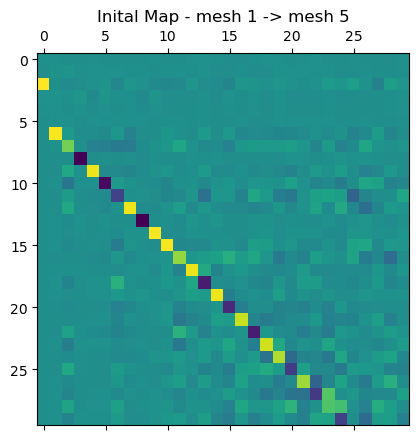

In [5]:
fmap = maps_dict[(0,5)]
plt.matshow(fmap)
plt.title(f"Inital Map - mesh {1} -> mesh {5}")
plt.show()

## Optimisation?

In [ ]:
def optimised_dict(mesh_list, interval_size=2, bidirectional=True, K=30):
    optimised_dict = {}
    n_meshes = len(mesh_list)

    for i in tqdm(range(n_meshes)):
        source_mesh = mesh_list[i]

        for k in range(1, interval_size + 1):
            j = i + k 
            if j < n_meshes:
                target_mesh = mesh_list[j]

                # Compute inital maps
                verts_i, verts_j = np.asarray(source_mesh.vertices), np.asarray(target_mesh.vertices)
                p2p_ji = initial_p2p_map(verts_j, verts_i)

                # Convert to functional maps
                FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, source_mesh, target_mesh, dims=K)
                optimised_dict[(i, j)] = FM_ij

                if bidirectional:
                    p2p_ij = initial_p2p_map(verts_i, verts_j)
                    FM_ji = spectral.mesh_p2p_to_FM(p2p_ij, target_mesh, source_mesh, dims=K)
                    optimised_dict[(j, i)] = FM_ji
    
    print(optimised_dict.keys())

    for i in tqdm(range(n_meshes)):
        for j in range(n_meshes):
            if i == j or (i, j) in optimised_dict:
                continue

            # Look for a valid intermediate step
            for step in range(i + 1, j):
                if (i, step) in optimised_dict and (step, j) in optimised_dict:
                    FM_ij = optimised_dict[(i, step)] @ optimised_dict[(step, j)]
                    optimised_dict[(i, j)] = FM_ij

                    if bidirectional and (j, step) in optimised_dict and (step, i) in optimised_dict:
                        FM_ji = optimised_dict[(j, step)] @ optimised_dict[(step, i)]
                        optimised_dict[(j, i)] = FM_ji
                    break  # Stop after first valid composition - if it works I'll put a condition to find the best step

    print("All optimised pairs:", optimised_dict.keys())
    return optimised_dict

In [30]:
new_dict = optimised_dict(mesh_list, 2)

print(f"maps_dict = {len(maps_dict)}")
print(f"optimised_dict = {len(new_dict)}")

  0%|          | 0/10 [00:00<?, ?it/s]

dict_keys([(0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3), (3, 5), (5, 3), (4, 5), (5, 4), (4, 6), (6, 4), (5, 6), (6, 5), (5, 7), (7, 5), (6, 7), (7, 6), (6, 8), (8, 6), (7, 8), (8, 7), (7, 9), (9, 7), (8, 9), (9, 8)])


  0%|          | 0/10 [00:00<?, ?it/s]

All optimised pairs: dict_keys([(0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3), (3, 5), (5, 3), (4, 5), (5, 4), (4, 6), (6, 4), (5, 6), (6, 5), (5, 7), (7, 5), (6, 7), (7, 6), (6, 8), (8, 6), (7, 8), (8, 7), (7, 9), (9, 7), (8, 9), (9, 8), (0, 3), (3, 0), (0, 4), (4, 0), (0, 5), (5, 0), (0, 6), (6, 0), (0, 7), (7, 0), (0, 8), (8, 0), (0, 9), (9, 0), (1, 4), (4, 1), (1, 5), (5, 1), (1, 6), (6, 1), (1, 7), (7, 1), (1, 8), (8, 1), (1, 9), (9, 1), (2, 5), (5, 2), (2, 6), (6, 2), (2, 7), (7, 2), (2, 8), (8, 2), (2, 9), (9, 2), (3, 6), (6, 3), (3, 7), (7, 3), (3, 8), (8, 3), (3, 9), (9, 3), (4, 7), (7, 4), (4, 8), (8, 4), (4, 9), (9, 4), (5, 8), (8, 5), (5, 9), (9, 5), (6, 9), (9, 6)])
maps_dict = 90
optimised_dict = 90


original map shape: (30, 30)


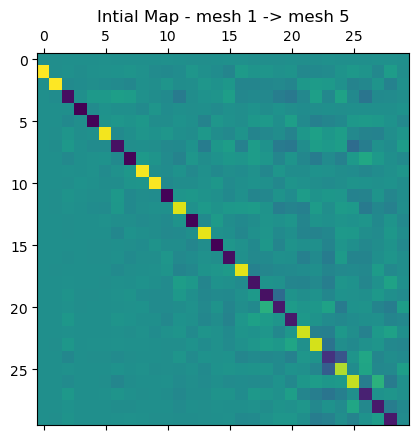

In [6]:
ind_1 = 0
ind_2 = 4

o_map = maps_dict[(ind_1,ind_2)]
print(f"original map shape: {o_map.shape}")

plt.matshow(o_map)
plt.title(f"Intial Map - mesh {ind_1+1} -> mesh {ind_2+1}")
plt.show()

# Test Display
mesh_1 = mesh_list_o3d[ind_1]; mesh_2 = mesh_list_o3d[ind_2]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

# print(verts_1.shape)
# print(verts_2.shape)
# print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

## 2. Consistent Zoomout _______________________________________________
1. Create Functional Map Network (FMN)
2. Run ConsistentZoomout refinement
3. Visualise Results by converting refined maps back to point to point maps

In [7]:
from FMN_Edited import FMN_Edited

# Build the network
fmn_model = FMN_Edited(mesh_list, maps_dict.copy())

Setting 90 edges on 10 nodes.


In [1]:
# add composite maps for missing edges?
ind_1 = 0
ind_2 = 4

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]

new_maps_dict = fmn_model.maps
map_1_10 = new_maps_dict[(ind_1, ind_2)]

print(f"new map shape: {map_1_10.shape}")

plt.matshow(map_1_10)
plt.title(f"C mat before ZoomOut - mesh {ind_1+1} -> mesh {ind_2+1}")
plt.show()

map_1_2 = new_maps_dict[(0,1)]
map_2_3 = new_maps_dict[(1,2)]
map_3_4 = new_maps_dict[(2,3)]
map_4_5 = new_maps_dict[(3,4)]

# map_5_6 = new_maps_dict[(4,5)]
# map_6_7 = new_maps_dict[(5,6)]
# map_7_8 = new_maps_dict[(6,7)]
# map_8_9 = new_maps_dict[(7,8)]
# map_9_10 = new_maps_dict[(8,9)]

comp_map_1_10 = map_1_2 @ map_2_3 @ map_3_4 @ map_4_5 #@ map_5_6 @ map_6_7 @ map_7_8 @ map_8_9 @ map_9_10
plt.matshow(comp_map_1_10)
plt.title(f"composite map 1 to 10")
plt.show()




NameError: name 'mesh_list' is not defined

In [63]:
# Run Consistent Zoomout
# fmn_model.compute_CCLB(m=20)
fmn_model.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='new',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True, alpha=0.2,beta=2,interval=2)

Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [8]:
# To Save or Load Model
import pickle as p

# #save
# with open("../../fmn_model_10_w_seq_decay_from_CZ.pkl", "wb") as f:
#     p.dump(fmn_model, f)

# load
with open("../../fmn_model_10_w_seq_decay_from_CZ.pkl", "rb") as f:
    fmn_model = p.load(f)

# 3. Evaulate Model Perfromance and Results _____________________ [not working]

In [9]:
from pyFM.FMN import FMN
fmn_model_old = FMN(mesh_list, maps_dict.copy())
# fmn_model_old.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='icsm',
#                     M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
#                     verbose=True)
# # save
# with open("../../fmn_model_10_from_CZ.pkl", "wb") as f:
#     p.dump(fmn_model_old.maps, f)

# load
with open("../../fmn_model_10_from_CZ.pkl", "rb") as f:
    fmn_model_old.maps = p.load(f)

Setting 90 edges on 10 nodes.


Optimizing Cycle Weights...
	Done in 0.00917s
Computing 78 CLB eigenvectors...
	Done in 0.1s


Text(0.5, 1.0, 'Conformal CSD')

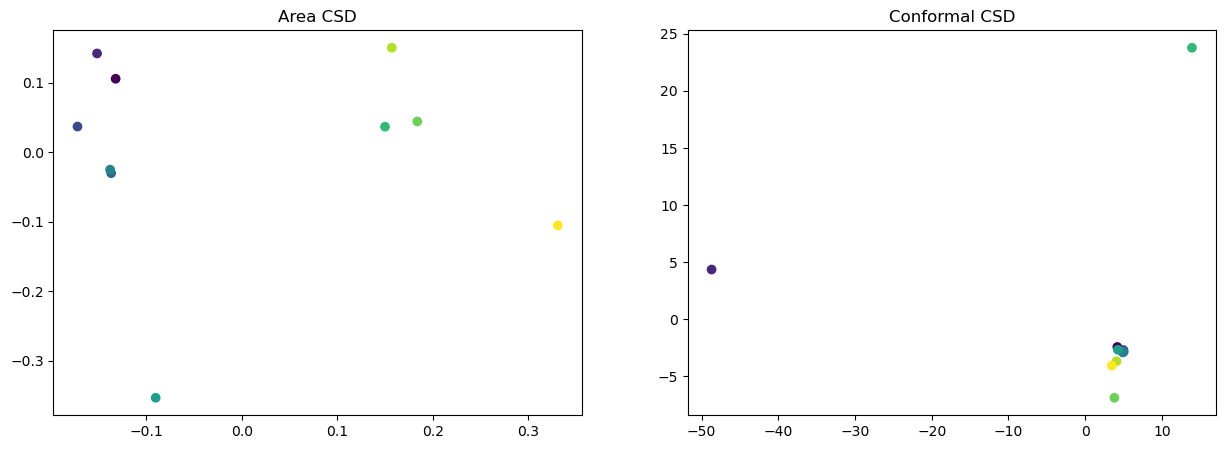

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fmn_model.compute_CCLB(m=int(0.9*fmn_model.M))
fmn_model.cclb_eigenvalues.shape
all_embs_a = []
all_embs_c = []

for i in range(fmn_model.n_meshes):
    CSD_a, CSD_c = fmn_model.get_CSD(i)

    all_embs_a.append(CSD_a.flatten())
    all_embs_c.append(CSD_c.flatten())

all_embs_a = np.array(all_embs_a)
all_embs_c = np.array(all_embs_c)

pca_model = PCA(n_components=2)
emb_red_a = pca_model.fit_transform(all_embs_a)
emb_red_c = pca_model.fit_transform(all_embs_c)

_, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].scatter(emb_red_a[:, 0], emb_red_a[:, 1], c=np.arange(len(emb_red_a)))
axs[0].set_title('Area CSD')

axs[1].scatter(emb_red_c[:, 0], emb_red_c[:, 1], c=np.arange(len(emb_red_c)))
axs[1].set_title('Conformal CSD')

# RUN THIS FOR VIS

In [10]:
def double_fm_display(ind_1, ind_2, maps1, maps2, mesh_display=False, meshes=None):
    
    fm_12_1 = maps1[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12_1.shape}")
    plt.matshow(fm_12_1)
    plt.title(f"Original Weight Scheme - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()


    fm_12_2 = maps2[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12_2.shape}")
    plt.matshow(fm_12_2)
    plt.title(f"Sequential Weight Scheme - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
        cmap_1 = visu(mesh1.vertlist)

        p2p_21_1 = spectral.convert.mesh_FM_to_p2p(fm_12_1, mesh1, mesh2)
        p2p_21_2 = spectral.convert.mesh_FM_to_p2p(fm_12_2, mesh1, mesh2)

        cmap_2_1 = cmap_1[p2p_21_1]
        cmap_2_2 = cmap_1[p2p_21_2]

        double_plot(mesh2, mesh2, cmap_2_1, cmap_2_2)

new map shape: (78, 78)


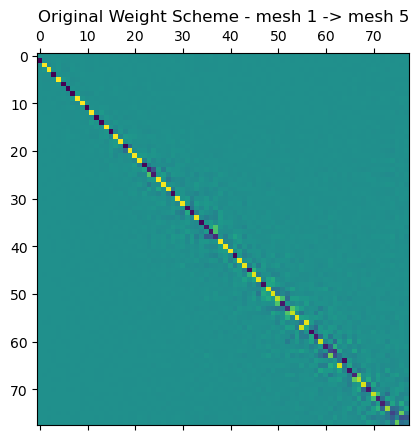

new map shape: (78, 78)


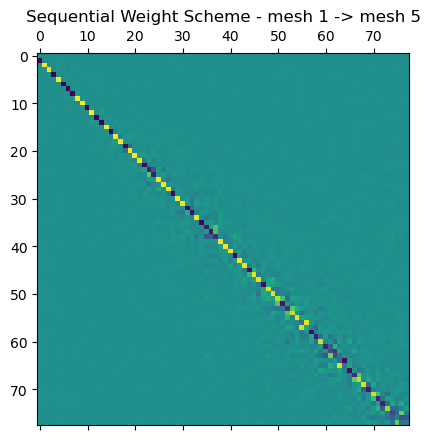

In [ ]:
ind_1 = 0
ind_2 = 4

new_maps_dict = fmn_model_old.maps
old_maps_dict = fmn_model_old.maps

double_fm_display(ind_1, ind_2, old_maps_dict, new_maps_dict, mesh_display=True, meshes=mesh_list)

new map shape: (78, 78)


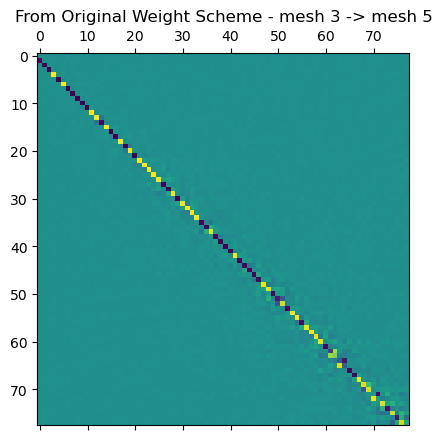

KeyboardInterrupt: 

In [11]:
# For Display
ind_1 = 2
ind_2 = 4

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]

new_maps_dict = fmn_model_old.maps
map_1_3 = new_maps_dict[(ind_1, ind_2)]

print(f"new map shape: {map_1_3.shape}")

plt.matshow(map_1_3)
plt.title(f"From Original Weight Scheme - mesh {ind_1+1} -> mesh {ind_2+1}")
plt.show()

# map_1_2 = new_maps_dict[(0,1)]
# map_2_3 = new_maps_dict[(1,2)]
# map_3_4 = new_maps_dict[(2,3)]
# map_4_5 = new_maps_dict[(3,4)]

# map_5_6 = new_maps_dict[(4,5)]
# map_6_7 = new_maps_dict[(5,6)]
# map_7_8 = new_maps_dict[(6,7)]
# map_8_9 = new_maps_dict[(7,8)]
# map_9_10 = new_maps_dict[(8,9)]

# comp_map = map_1_2 @ map_2_3 @ map_3_4 @ map_4_5 @ map_5_6 @ map_6_7 @ map_7_8 @ map_8_9 @ map_9_10
# plt.matshow(comp_map)
# plt.title(f"composite map 1 to 10")
# plt.show()


# mesh1_o3d, mesh2_o3d = mesh_list_o3d[ind_1], mesh_list_o3d[ind_2]
# verts_o3d = np.asarray(mesh1_o3d.vertices)

p2p_15 = spectral.convert.mesh_FM_to_p2p(map_1_3, mesh1, mesh2) # need to look at this function properly

cmap_1 = visu(mesh1.vertlist)
cmap_2 = cmap_1[p2p_15]
double_plot(mesh1, mesh2, cmap_1, cmap_2)

# print(mesh1.vertlist.shape)
# print(mesh2.vertlist.shape)
# print(p2p_21.shape)


In [ ]:
import numpy as np
from scipy.spatial import KDTree

def normalize_scale(P):
    """
    Centers the point cloud P and scales it based on the Root Mean Square (RMS)
    distance from the center. This ensures scale invariance.
   
    Args:
        P (np.ndarray): The point cloud matrix (N x 3).
       
    Returns:
        np.ndarray: The normalized point cloud P'.
    """
    # 1. Center the cloud
    center = np.mean(P, axis=0)
    P_centered = P - center
   
    # 2. Calculate RMS distance from the center (size measure)
    rms_size = np.sqrt(np.mean(np.sum(P_centered**2, axis=1)))
   
    # 3. Normalize (avoid division by zero if all points are identical)
    if rms_size > 1e-6:
        P_normalized = P_centered / rms_size
    else:
        P_normalized = P_centered # Already very small/degenerate
       
    return P_normalized

def chamfer_distance(A, B):
    """
    Calculates the squared Chamfer Distance between two point clouds A and B.
   
    Args:
        A (np.ndarray): The first point cloud (m x 3).
        B (np.ndarray): The second point cloud (n x 3).
       
    Returns:
        float: The squared Chamfer Distance.
    """
    # Build a KD-Tree for efficient nearest neighbor search
    tree_B = KDTree(B)
    tree_A = KDTree(A)

    # Term 1: Distance from A to B (B is the target)
    # query returns: distances, indices
    dist_A_to_B, _ = tree_B.query(A)
    sum_A_to_B = np.sum(dist_A_to_B**2)
   
    # Term 2: Distance from B to A (A is the target)
    dist_B_to_A, _ = tree_A.query(B)
    sum_B_to_A = np.sum(dist_B_to_A**2)

    # Chamfer Distance (Averaged two-way squared distance)
    cd = (sum_A_to_B / len(A)) + (sum_B_to_A / len(B))
   
    return cd

def compare_reconstructions(Actual_A, Reconstructed_B1):#, Reconstructed_B2):
    """
    Compares two reconstruction methods (B1 and B2) against the actual matrix (A)
    using scale-normalized Chamfer Distance.
    """
    #print("--- Normalizing Point Clouds for Scale Invariance ---")
   
    # Normalize all matrices
    A_norm = normalize_scale(Actual_A)
    B1_norm = normalize_scale(Reconstructed_B1)
    #B2_norm = normalize_scale(Reconstructed_B2)

    # Calculate CD for Method 1
    cd1 = chamfer_distance(A_norm, B1_norm)
    #print(f"\nMethod 1 CD: {cd1:.6f}")
    return cd1
   
    # # Calculate CD for Method 2
    # cd2 = chamfer_distance(A_norm, B2_norm)
    # print(f"Method 2 CD: {cd2:.6f}")

    # print("\n--- Comparison Result ---")
    # if cd1 < cd2:
    #     print(f"✅ Method 1 is CLOSET to the actual matrix (A) with a smaller CD.")
    # elif cd2 < cd1:
    #     print(f"✅ Method 2 is CLOSET to the actual matrix (A) with a smaller CD.")
    # else:
    #     print("Both methods produced a similar reconstruction error.")

In [1]:
def mesh_euclidean_error(p2p_map, source_mesh, target_mesh):
    src_points = np.asarray(source_mesh.vertices)
    trgt_points = np.asarray(target_mesh.vertices)

    mapped_trgt_points = src_points[p2p_map]
    pointwise_errors = np.linalg.norm(trgt_points - mapped_trgt_points, axis=1) # distance accross each row

    return pointwise_errors

# def mesh_euclidean_error(p2p_map_1, source_mesh):
#     src_points = np.asarray(source_mesh.vertices)

#     mapped_trgt_points = src_points[p2p_map_1]
#     #print(mapped_trgt_points.shape)
#     #mapped_points_old = src_points[p2p_map_2] 
#     #double_pcd_plot(src_points, mapped_trgt_points)

#     #pointwise_errors = np.linalg.norm(src_points - mapped_trgt_points, axis=1) # distance accross each row
#     pointwise_errors = compare_reconstructions(src_points, mapped_trgt_points)

#     return pointwise_errors

errors_new = {}
errors_old = {}
new_maps_dict = fmn_model.maps
old_maps_dict = fmn_model_old.maps

for i in range(len(mesh_list)):
    for j in tqdm(range(len(mesh_list)), "Just Trying to Keep track of each iteration"):
        if i == j:
            continue

        mesh1, mesh2 = mesh_list[i], mesh_list[j]
        new_map_ij = new_maps_dict[(i, j)]
        initial_map_ij = old_maps_dict[(i, j)]

        new_p2p = spectral.convert.mesh_FM_to_p2p(new_map_ij, mesh1, mesh2)
        old_p2p = spectral.convert.mesh_FM_to_p2p(initial_map_ij, mesh1, mesh2)

        err_new = mesh_euclidean_error(new_p2p, mesh1)
        err_old = mesh_euclidean_error(old_p2p, mesh1)

        errors_new[(i, j)] = err_new
        errors_old[(i, j)] = err_old

# with open("errors_new_CZ.json", "wb") as f:
#     p.dump(errors_new, f)

# with open("errors_old_CZ.json", "wb") as f:
#     p.dump(errors_initial, f)

NameError: name 'fmn_model' is not defined

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

...

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

0.01335845084285199


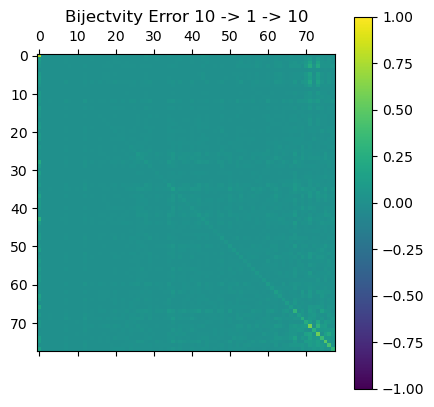

0.01335845084285199


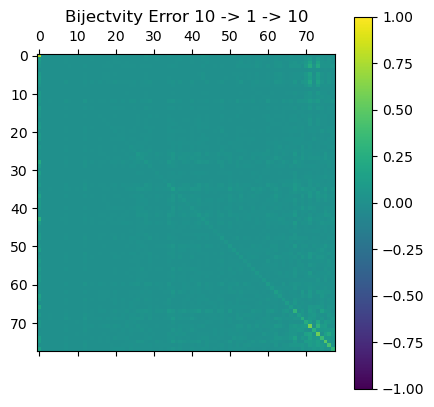

0.013056545178434334


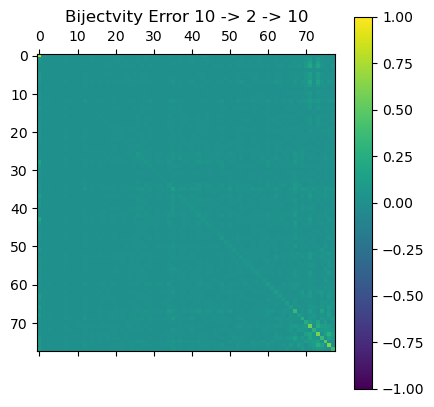

0.013056545178434334


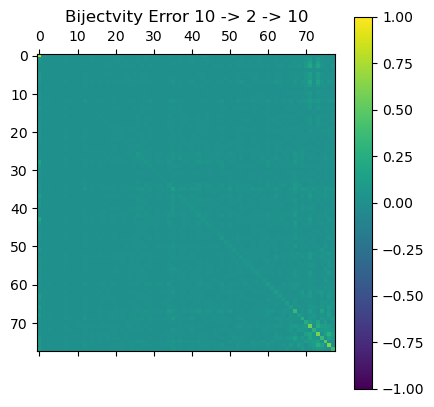

0.013345350880228576


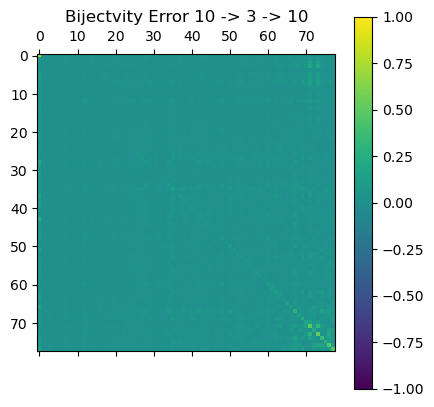

0.013345350880228576


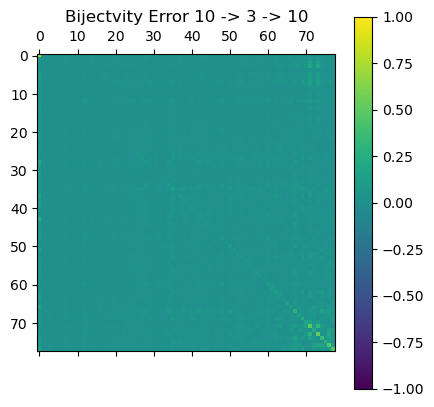

0.013153018778573196


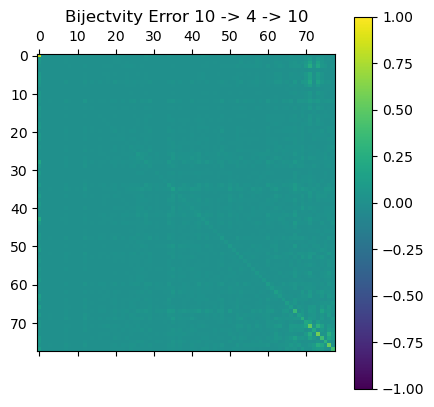

0.013153018778573196


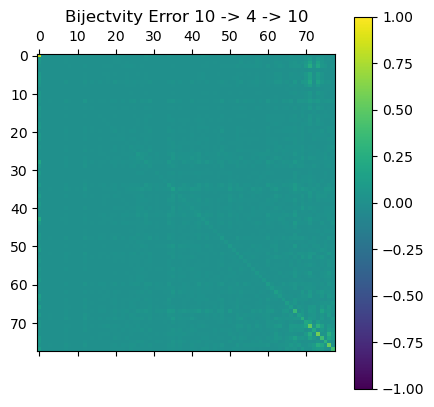

0.013326560656380956


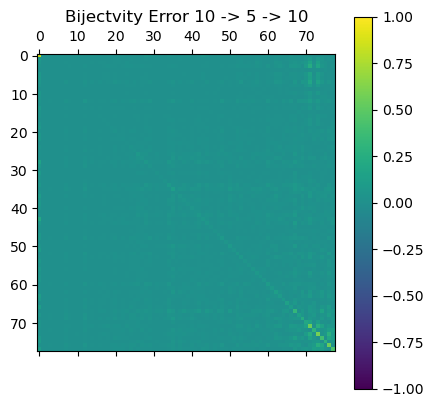

0.013326560656380956


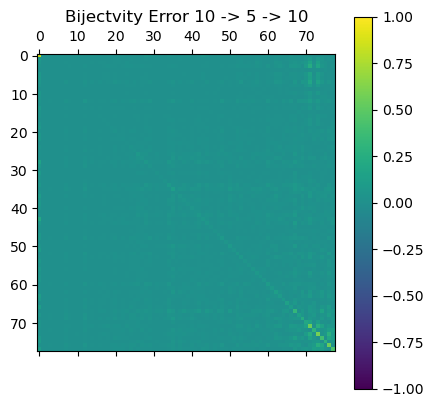

0.015494192822267189


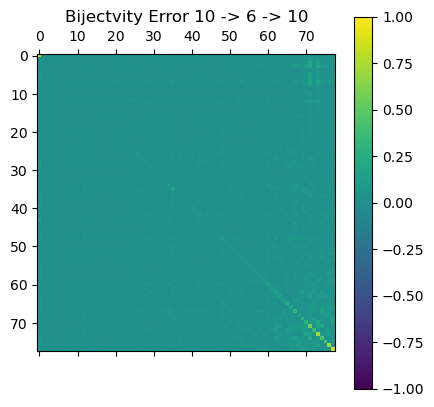

0.015494192822267189


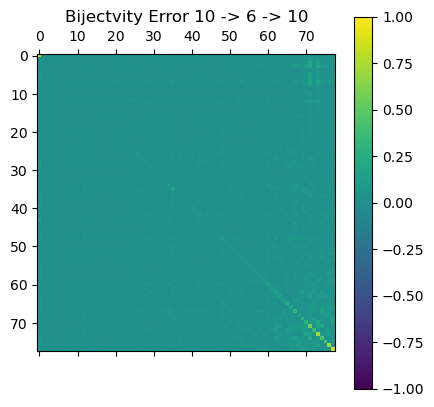

0.0070907372453709525


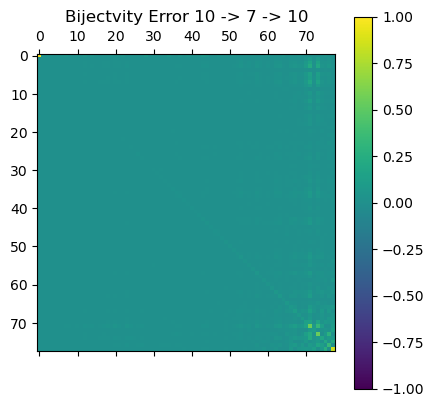

0.0070907372453709525


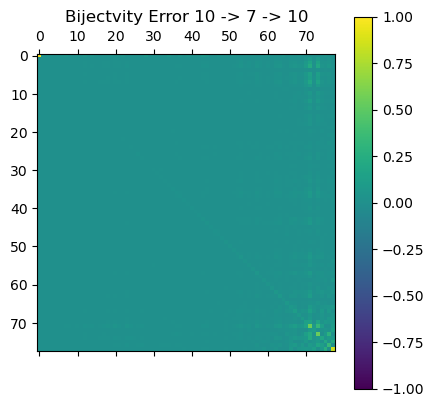

0.002764911708189161


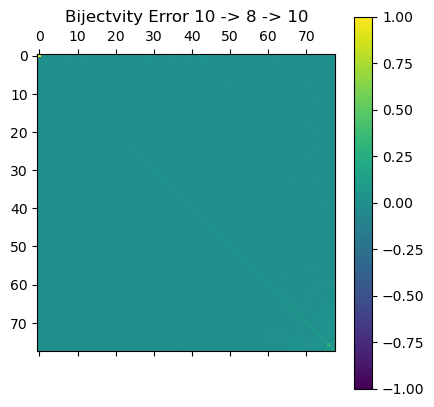

0.002764911708189161


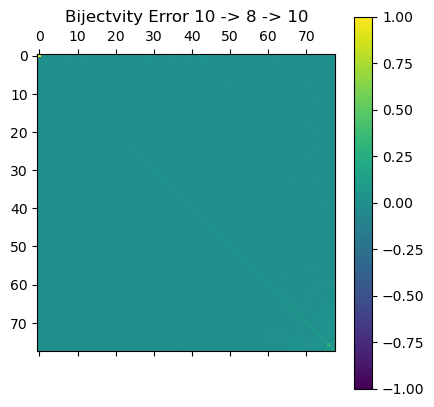

0.002791796009012442


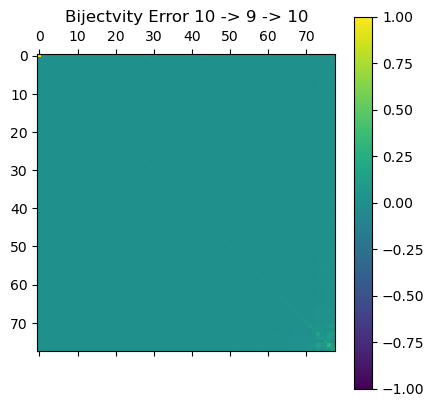

0.002791796009012442


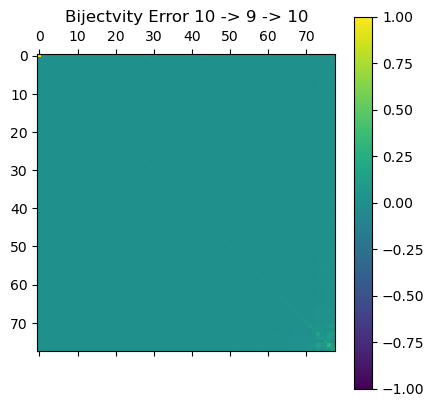

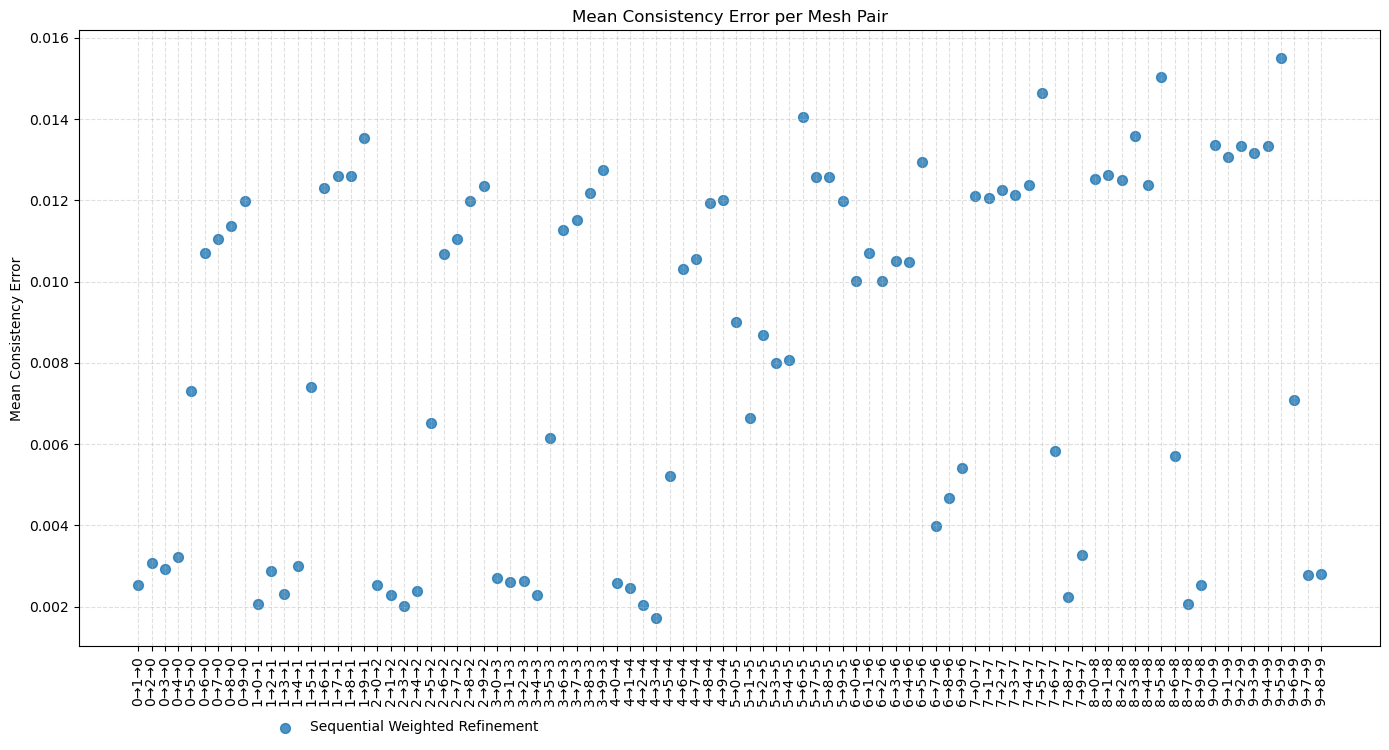

In [32]:
def check_cycle_consistency(map_ij, map_ji, i, j, show=False):
    compound = map_ji @ map_ij
    
    # Identity for shape Si
    identity = np.eye(map_ij.shape[0])
    #error = np.linalg.norm(identity - compound)
        # plt.matshow(compound, vmin=-1, vmax=1)
        # plt.title(f"S{ind_1+1} → S{ind_2+1} → S{ind_1+1}")
        # plt.colorbar()

    elementwise_error = np.abs(identity - compound)
    
    if show:
        print(np.mean(elementwise_error))

        plt.matshow(elementwise_error, vmin=-1, vmax=1)
        plt.title(f"Bijectvity Error {i+1} -> {j+1} -> {i+1}")
        plt.colorbar()

        plt.show()

    return np.mean(elementwise_error)

bijectivity_new_errors = []
bijectivity_old_errors = []
map_labels = []

for i in range(len(mesh_list)):
    for j in tqdm(range(len(mesh_list)), "Just Trying to Keep track of each iteration"):
        if i == j:
            continue

        if i == 9:
            showw = True
        else:
            showw = False

        mesh1, mesh2 = mesh_list[i], mesh_list[j]
        
        new_map_ij = new_maps_dict[(i, j)]
        old_map_ij = old_maps_dict[(i, j)]

        new_map_ji = new_maps_dict[(j, i)]
        old_map_ji = old_maps_dict[(j, i)]

        err_new = check_cycle_consistency(new_map_ij, new_map_ji, i, j, showw)
        err_old = check_cycle_consistency(old_map_ij, old_map_ji, i, j, showw)

        bijectivity_new_errors.append(err_new)
        bijectivity_old_errors.append(err_old)

        map_labels.append(f"{i}→{j}→{i}")

plt.figure(figsize=(14,8))

plt.scatter(range(len(bijectivity_new_errors)), bijectivity_new_errors, c='tab:blue', label='Sequential Weighted Refinement', s=50, alpha=0.8)
#plt.scatter(range(len(bijectivity_old_errors)), bijectivity_old_errors, c='tab:orange', label='Original Refinement', s=50, alpha=0.8)
plt.xticks(range(len(bijectivity_new_errors)), map_labels, rotation=90)
plt.ylabel("Mean Consistency Error")
plt.title("Mean Consistency Error per Mesh Pair")

# Legend below the x-axis
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.25, -0.1),  # position below the axis
    ncol=2,                       # number of columns
    frameon=False                 # optional: cleaner look
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave extra space for the legend
plt.show()

90


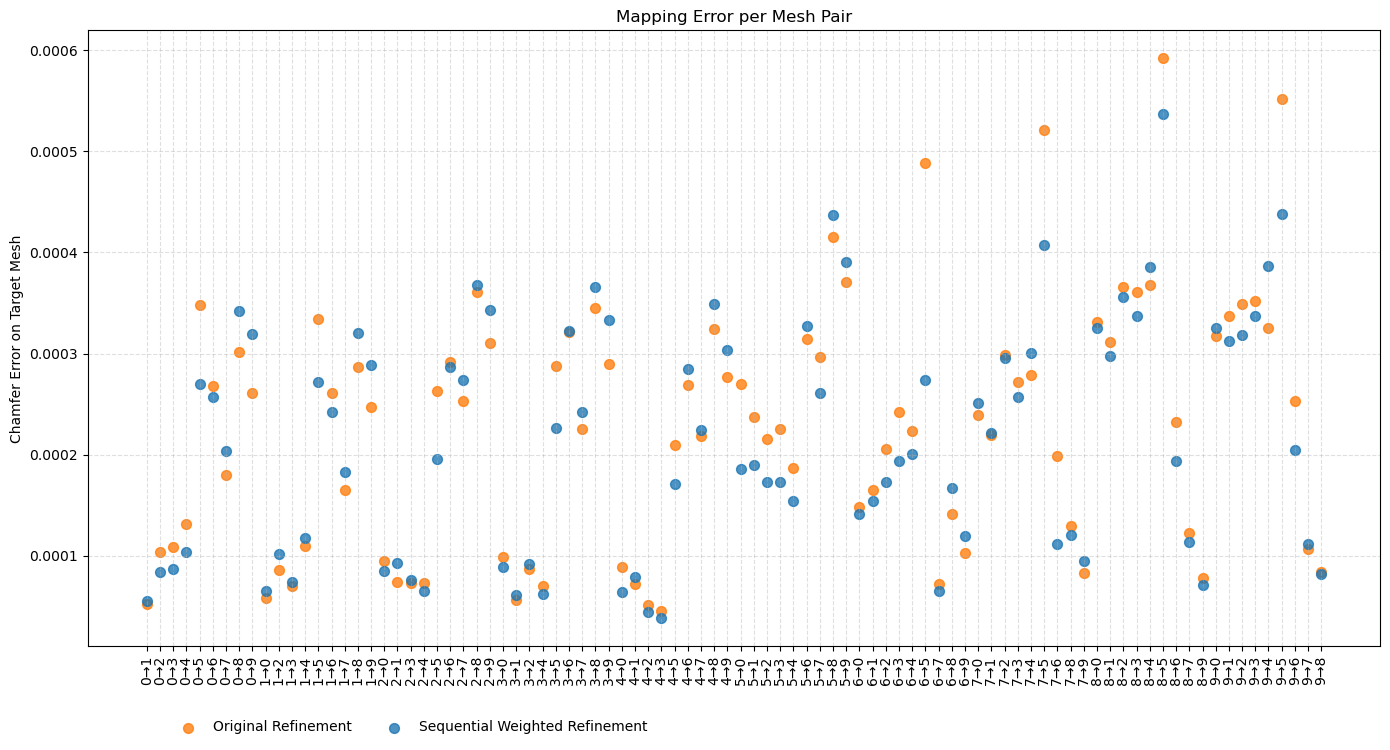

In [ ]:
def ordered_weighted_mean(errors, sigma_factor=0.25, normalize_variance=True):

    errors = np.asarray(errors)
    n = len(errors)
    if n == 0:
        return np.nan, None

    # Sort the errors
    sorted_errors = np.sort(errors)

    # Rank positions (0 to 1)
    ranks = np.linspace(-1, 1, n)

    # Compute Gaussian-like weights centered at 0
    sigma = sigma_factor
    weights = np.exp(-0.5 * (ranks / sigma)**2)

    # Normalize weights to sum to 1
    weights /= np.sum(weights)

    # Optionally normalize to unit variance (weights distribution only)
    if normalize_variance:
        weights = weights / np.sqrt(np.sum(weights**2))

    # Weighted mean
    owm = np.sum(weights * sorted_errors)
    return owm

list_errors_new = []
list_errors_old = []

map_labels = []

for (i, j) in errors_new:
    list_errors_new.append(errors_new[(i, j)])
    list_errors_old.append(errors_old[(i, j)])
    
    map_labels.append(f"{i}→{j}")

print(len(list_errors_new))

# Plot
plt.figure(figsize=(14,8))

plt.scatter(range(len(list_errors_old)), list_errors_old, c='tab:orange', label='Original Refinement', s=50, alpha=0.8)
plt.scatter(range(len(list_errors_new)), list_errors_new, c='tab:blue', label='Sequential Weighted Refinement', s=50, alpha=0.8)

plt.xticks(range(len(errors_new)), map_labels, rotation=90)
plt.ylabel("Chamfer Error on Target Mesh")
plt.title("Mapping Error per Mesh Pair")

# Legend below the x-axis
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.25, -0.1),  # position below the axis
    ncol=2,                       # number of columns
    frameon=False                 # optional: cleaner look
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave extra space for the legend
plt.show()

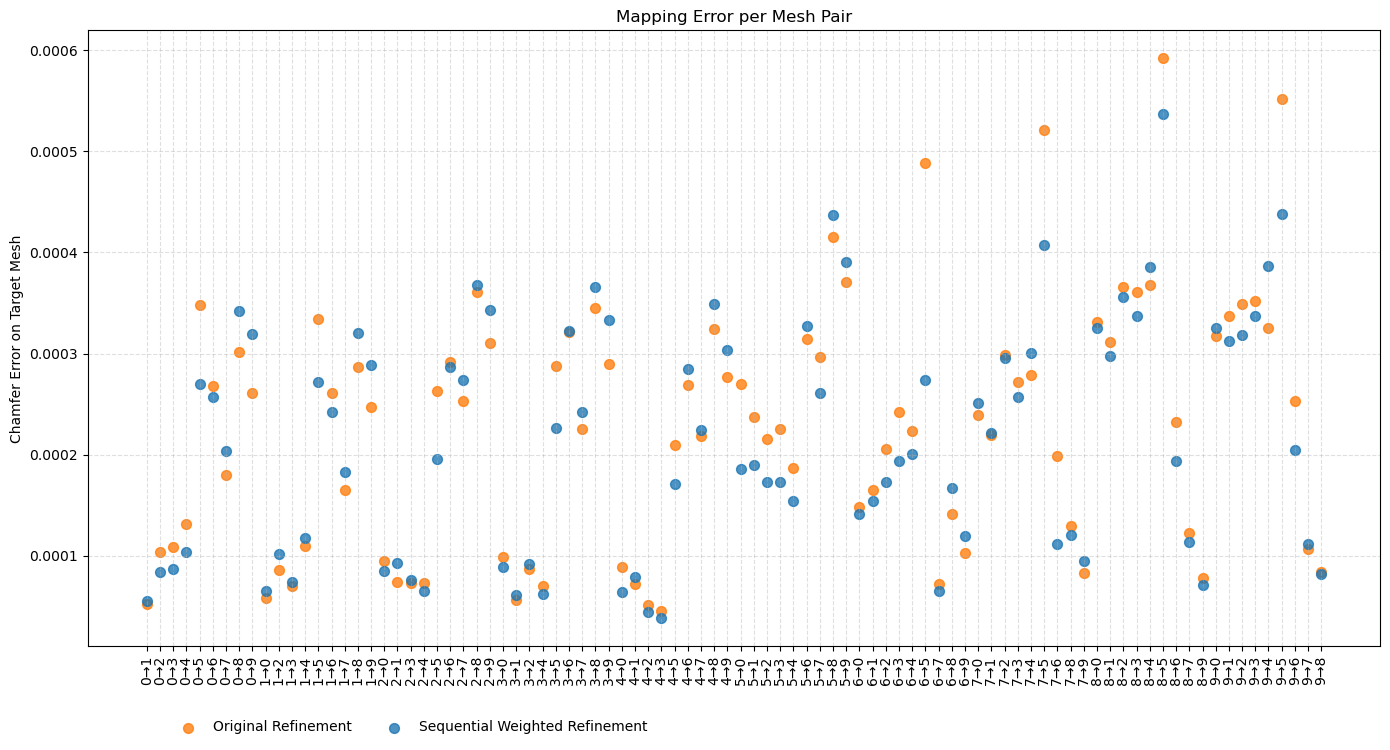

In [145]:
plt.figure(figsize=(14,8))

plt.scatter(range(len(list_errors_old)), list_errors_old, c='tab:orange', label='Original Refinement', s=50, alpha=0.8)
plt.scatter(range(len(list_errors_new)), list_errors_new, c='tab:blue', label='Sequential Weighted Refinement', s=50, alpha=0.8)

plt.xticks(range(len(errors_new)), map_labels, rotation=90)
plt.ylabel("Chamfer Error on Target Mesh")
plt.title("Mapping Error per Mesh Pair")

# Legend below the x-axis
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.25, -0.1),  # position below the axis
    ncol=2,
    frameon=False
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

ValueError: x and y must be the same size

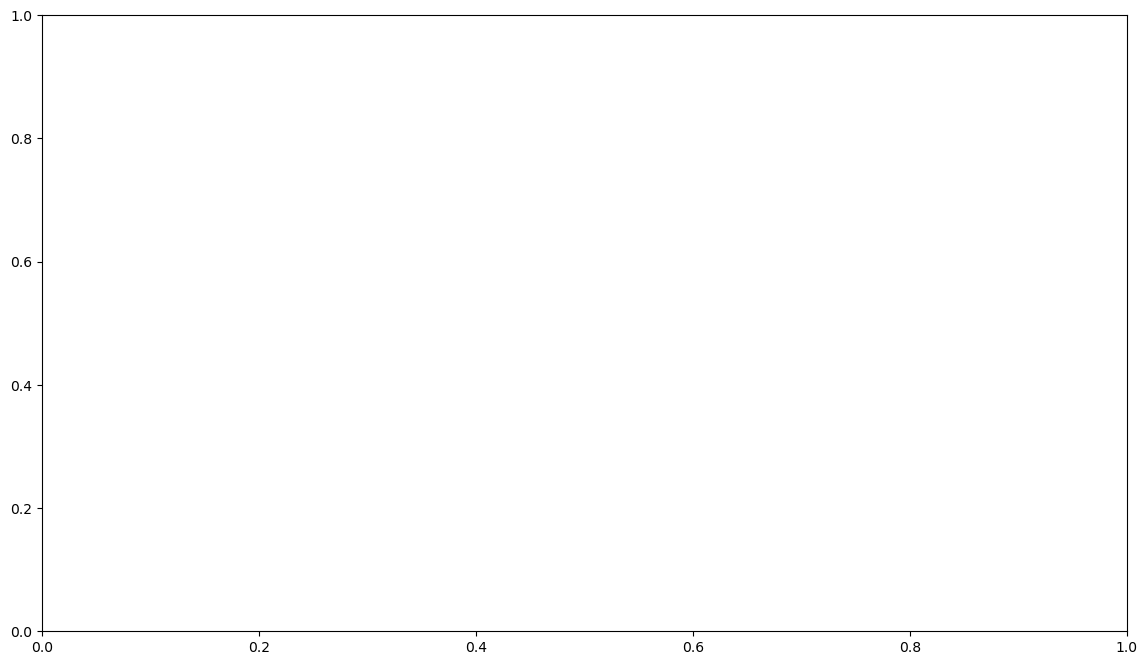

In [122]:
plt.figure(figsize=(14,8))

plt.scatter(range(len(errors_old)), errors_old, 
            c='tab:orange', label='Original Pointwise Refinement', s=50, alpha=0.8)

plt.scatter(range(len(errors_new)), errors_new, 
            c='tab:blue', label='Sequential Weighted Refinement', s=50, alpha=0.8)

plt.xticks(range(len(map_labels)), map_labels, rotation=90)
plt.ylabel("Chamfer Error on Target Mesh")
plt.title("Mapping Error per Mesh Pair")

plt.legend(loc='upper center', bbox_to_anchor=(0.25, -0.1), ncol=2, frameon=False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

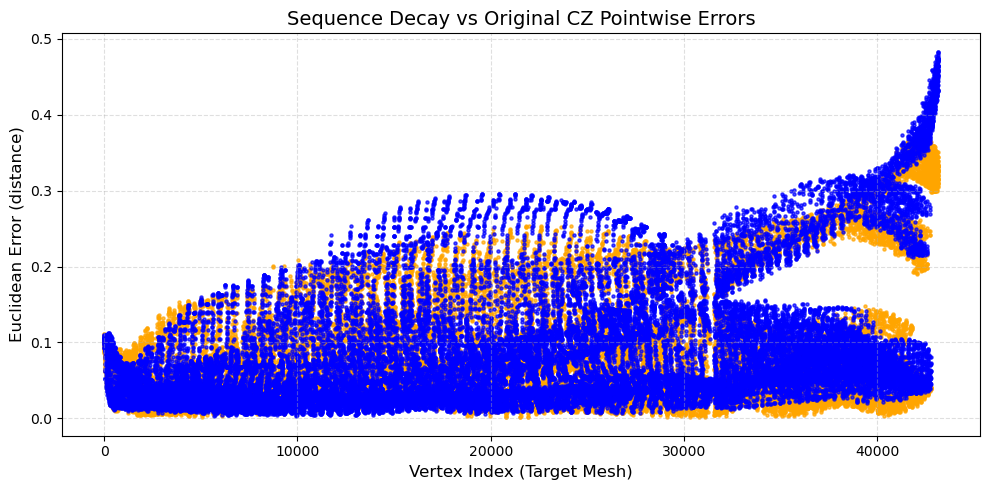

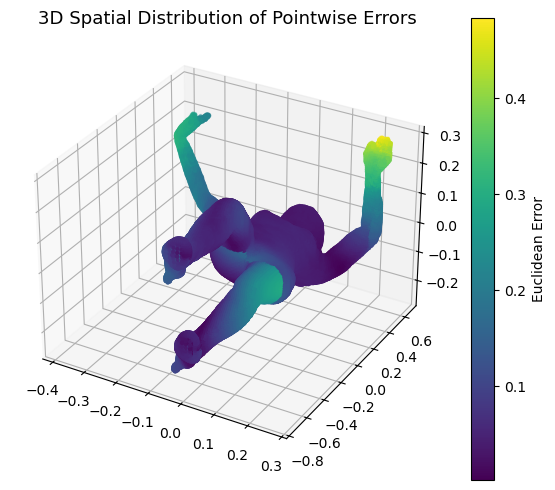

In [41]:
from mpl_toolkits.mplot3d import Axes3D

def plot_pointwise_errors_3d(target_mesh, errors, cmap='viridis'):
    verts = np.asarray(target_mesh.vertices)
    errors = np.asarray(errors)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(verts[:,0], verts[:,1], verts[:,2],
                    c=errors, cmap=cmap, s=4)
    plt.colorbar(sc, ax=ax, label="Euclidean Error")
    ax.set_title("3D Spatial Distribution of Pointwise Errors", fontsize=13)
    plt.show()

ind_1 = 0
ind_2 = 9
mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]
new_error = errors_new[(ind_1, ind_2)]
initial_error = errors_initial[(ind_1, ind_2)]

new_CZ_errors_arr = np.asarray(new_error)
x = np.arange(len(new_CZ_errors_arr))  # point indices

old_CZ_errors_arr = np.asarray(initial_error)
x_1 = np.arange(len(old_CZ_errors_arr))  # point indices

plt.figure(figsize=(10, 5))
plt.scatter(x_1, old_CZ_errors_arr, s=5, alpha=0.7, color="orange")
plt.scatter(x, new_CZ_errors_arr, s=5, alpha=0.7, color="blue")

plt.title('Sequence Decay vs Original CZ Pointwise Errors', fontsize=14)
plt.xlabel("Vertex Index (Target Mesh)", fontsize=12)
plt.ylabel("Euclidean Error (distance)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plot_pointwise_errors_3d(mesh1, new_error)


In [76]:
# Setting up Plotting Functions
def double_pcd_plot(pts1, pts2, cmap1=None, cmap2=None):
    vertlist_1 = np.asarray(pts1)
    vertlist_2 = np.asarray(pts2)

    d = mp.subplot(vertlist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, c=cmap2, s=[2, 2, 1], data=d)

In [114]:
def mesh_euclidean_error(p2p_map_1, mesh_1, mesh_2):
    mesh_1_points = np.asarray(mesh_1.vertices)
    mesh_2_points = np.asarray(mesh_2.vertices)

    mapped_trgt_points = mesh_2_points[p2p_map_1]
    print(mapped_trgt_points.shape)
    
    double_pcd_plot(mesh_1_points, mapped_trgt_points)

    #pointwise_errors = np.linalg.norm(src_points - mapped_trgt_points, axis=1) # distance accross each row
    pointwise_errors = compare_reconstructions(mesh_1_points, mapped_trgt_points)

    return mapped_trgt_points, pointwise_errors

ind_1 = 0
ind_2 = 9
mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]

print(np.asarray(mesh1.vertices).shape)
print(np.asarray(mesh2.vertices).shape)

new_maps_dict = fmn_model.maps
old_maps_dict = fmn_model_old.maps

new_map = new_maps_dict[(ind_1, ind_2)]
new_p2p = spectral.convert.mesh_FM_to_p2p(new_map, mesh1, mesh2)

print(new_p2p.shape)

old_map = old_maps_dict[(ind_1, ind_2)]
old_p2p = spectral.convert.mesh_FM_to_p2p(old_map, mesh1, mesh2)

new_2, pt_error_new = mesh_euclidean_error(new_p2p, mesh1, mesh2)
old_2, pt_error_old = mesh_euclidean_error(old_p2p, mesh1, mesh2)

#compare_reconstructions(np.asarray(mesh1.vertices), new_p2p, old_p2p)


(43158, 3)
(39739, 3)
(39739,)


IndexError: index 42025 is out of bounds for axis 0 with size 39739

In [106]:
print(pt_error_new)

0.00031929805875431476


[0.00745491 0.00948285 0.00884951 ... 0.05034556 0.0438296  0.05020083]


/tmp/ipykernel_42296/2210823388.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 700x600 with 2 Axes> than <Figure size 700x600 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label="Euclidean Error")
/tmp/ipykernel_42296/2210823388.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 700x600 with 2 Axes> than <Figure size 700x600 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(m2, ax=ax_1, label="Original Mesh 2")


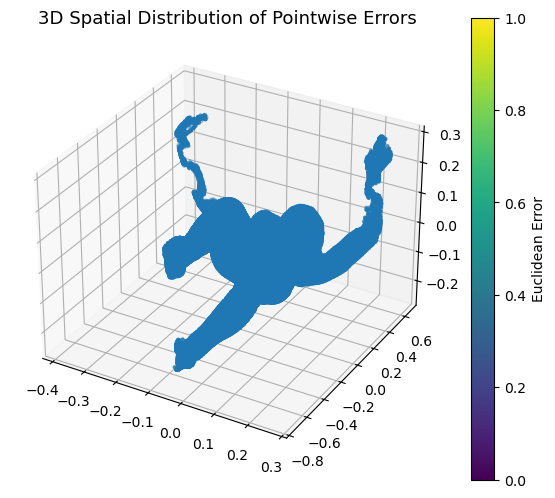

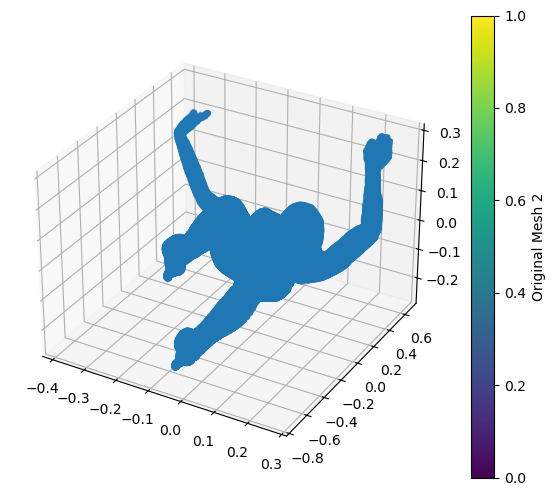

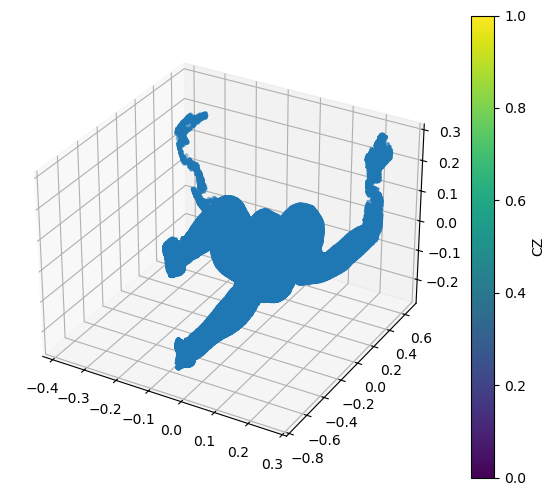

In [ ]:
print(pt_error_new)

new_CZ_errors_arr = np.asarray(pt_error_new)
x = np.arange(len(new_CZ_errors_arr))  # point indices

old_CZ_errors_arr = np.asarray(pt_error_old)
x_1 = np.arange(len(old_CZ_errors_arr))  # point indices

plt.figure(figsize=(10, 5))
plt.scatter(x_1, old_CZ_errors_arr, s=5, alpha=0.7, color="orange")
plt.scatter(x, new_CZ_errors_arr, s=5, alpha=0.7, color="blue")

plt.title('Sequence Decay vs Original CZ Pointwise Errors', fontsize=14)
plt.xlabel("Vertex Index (Target Mesh)", fontsize=12)
plt.ylabel("Euclidean Error (distance)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plot_pointwise_errors_3d(mesh1, new_error)


fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(new_2[:,0], new_2[:,1], new_2[:,2], s=4)

fig_1 = plt.figure(figsize=(7, 6))
ax_1 = fig_1.add_subplot(111, projection='3d')
m2 = ax_1.scatter(mesh1.vertices[:,0], mesh1.vertices[:,1], mesh1.vertices[:,2], s=4)

fig_2 = plt.figure(figsize=(7, 6))
ax_2 = fig_2.add_subplot(111, projection='3d')
m3 = ax_2.scatter(old_2[:,0], old_2[:,1], old_2[:,2], s=4)

plt.colorbar(sc, ax=ax, label="Euclidean Error")
plt.colorbar(m2, ax=ax_1, label="Original Mesh 2")
plt.colorbar(m3, ax=ax_2, label="CZ")

ax.set_title("3D Spatial Distribution of Pointwise Errors", fontsize=13)
plt.show()